# 3. Análisis exploratorio

Se parte de los archivos ya integrados y limpios (`data/videos_procesado.csv`, `data/comments_procesado.csv`), generados en la etapa de carga y limpieza.

In [1]:
import json
import re
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from wordcloud import WordCloud

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)

videos = pd.read_csv('data/videos_procesado.csv', encoding='utf-8-sig')
comments = pd.read_csv('data/comments_procesado.csv', encoding='utf-8-sig')

# query_hits y keywords se almacenan como texto con estructura de lista (ver 2.2)
videos['keywords_lista'] = videos['keywords'].apply(json.loads)
videos['query_hits_lista'] = videos['query_hits'].apply(json.loads)

comments_videos = comments.merge(
    videos[['video_id', 'title', 'channel_name', 'category', 'source_group', 'view_count']],
    on='video_id', how='left', suffixes=('', '_video'),
)

### 3.1 Descripción general (elementos mínimos)

In [2]:
print(f"Videos: {videos['video_id'].nunique()}")
print(f"Canales: {videos['channel_id'].nunique()}")
print(f"Comentarios: {comments['comment_id'].nunique()}")
print(f"Autores de comentarios: {comments['author_channel_id'].nunique()}")
print(f"Videos con al menos un comentario en la muestra: {comments['video_id'].nunique()}")

Videos: 293
Canales: 97
Comentarios: 406
Autores de comentarios: 332
Videos con al menos un comentario en la muestra: 19


Videos por canal — resumen:
count    97.000000
mean      3.020619
std       5.141699
min       1.000000
25%       1.000000
50%       1.000000
75%       2.000000
max      32.000000
dtype: float64


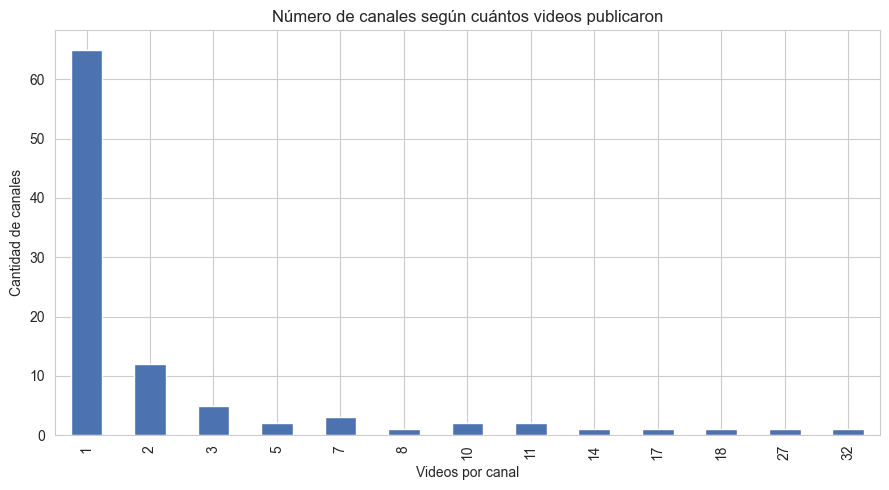

In [3]:
videos_por_canal = videos.groupby('channel_id').size()
print('Videos por canal — resumen:')
print(videos_por_canal.describe())
videos_por_canal.value_counts().sort_index().plot(kind='bar', color='#4C72B0')
plt.title('Número de canales según cuántos videos publicaron')
plt.xlabel('Videos por canal')
plt.ylabel('Cantidad de canales')
plt.tight_layout()
plt.show()

In [4]:
comentarios_por_video = comments.groupby('video_id').size().sort_values(ascending=False)
autores_por_video = comments.groupby('video_id')['author_channel_id'].nunique().sort_values(ascending=False)

resumen_video = pd.DataFrame({
    'comentarios': comentarios_por_video,
    'autores_unicos': autores_por_video,
}).join(videos.set_index('video_id')[['title', 'channel_name']])

print('Comentarios y autores únicos por video (los 19 videos con comentarios):')
resumen_video[['title', 'channel_name', 'comentarios', 'autores_unicos']]

Comentarios y autores únicos por video (los 19 videos con comentarios):


,title,channel_name,comentarios,autores_unicos
video_id,,,,
n8iP75gIpmw,Qué rico come tu diputado,Quorum,161,128
j43HgwYFKfk,La cooptación de Walter Mazariegos en la USAC,Quorum,50,49
6W4u8sGEnGM,Inician los trabajos de recuperación del Puent...,Gobierno de la República de Guatemala,45,32
lj983NWyAQY,Plan 2032 Ciudad de Guatemala,Municipalidad de Guatemala,25,25
PjmxCj-a9Hg,Conferencia de Prensa del Gobierno de Guatemal...,Gobierno de la República de Guatemala,25,19
OkXlHx0hx-8,EE.UU. envía a mexicanos deportados a Guatemal...,Noticias Telemundo,25,18
yLZS3JiEBg8,Arroz con pollo a la MONOPOLIO,Quorum,16,16
06mFNPU0aB8,Capturan a presuntos delincuentes disfrazados ...,Noti7,14,13
ndAZjHqzzT8,Internet: escoger el menos malo,Quorum,12,10


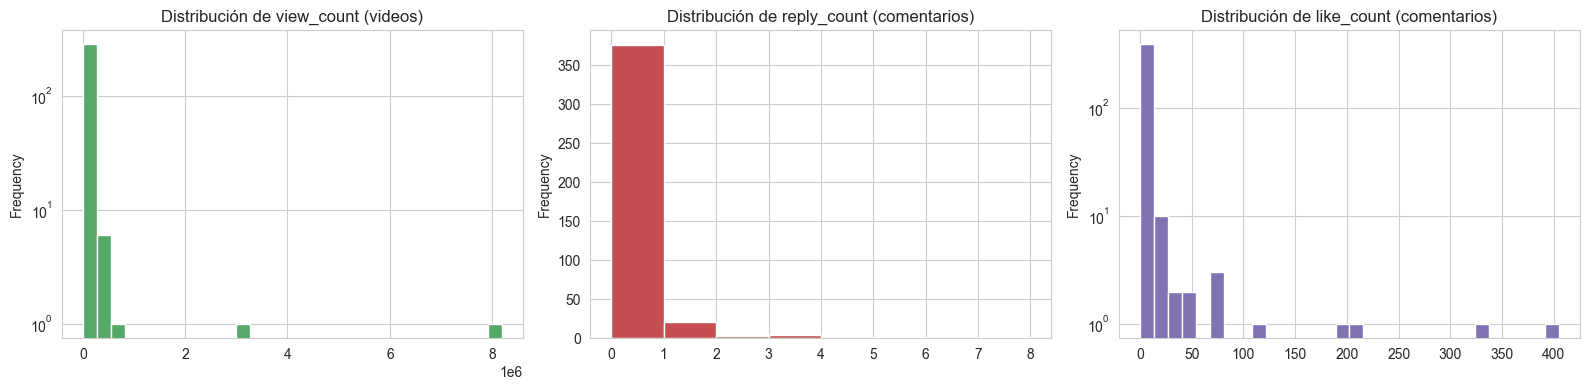

count    2.930000e+02
mean     6.043009e+04
std      5.157983e+05
min      2.000000e+00
25%      2.150000e+02
50%      1.175000e+03
75%      7.465000e+03
max      8.190449e+06
Name: view_count, dtype: float64
       reply_count  like_count
count   406.000000  406.000000
mean      0.125616    5.726601
std       0.580748   30.661298
min       0.000000    0.000000
25%       0.000000    0.000000
50%       0.000000    1.000000
75%       0.000000    2.000000
max       7.000000  405.000000


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
videos['view_count'].plot(kind='hist', bins=30, ax=axes[0], color='#55A868')
axes[0].set_title('Distribución de view_count (videos)')
axes[0].set_yscale('log')

comments['reply_count'].plot(kind='hist', bins=range(0, 9), ax=axes[1], color='#C44E52')
axes[1].set_title('Distribución de reply_count (comentarios)')

comments['like_count'].plot(kind='hist', bins=30, ax=axes[2], color='#8172B2')
axes[2].set_title('Distribución de like_count (comentarios)')
axes[2].set_yscale('log')
plt.tight_layout()
plt.show()

print(videos['view_count'].describe())
print(comments[['reply_count', 'like_count']].describe())

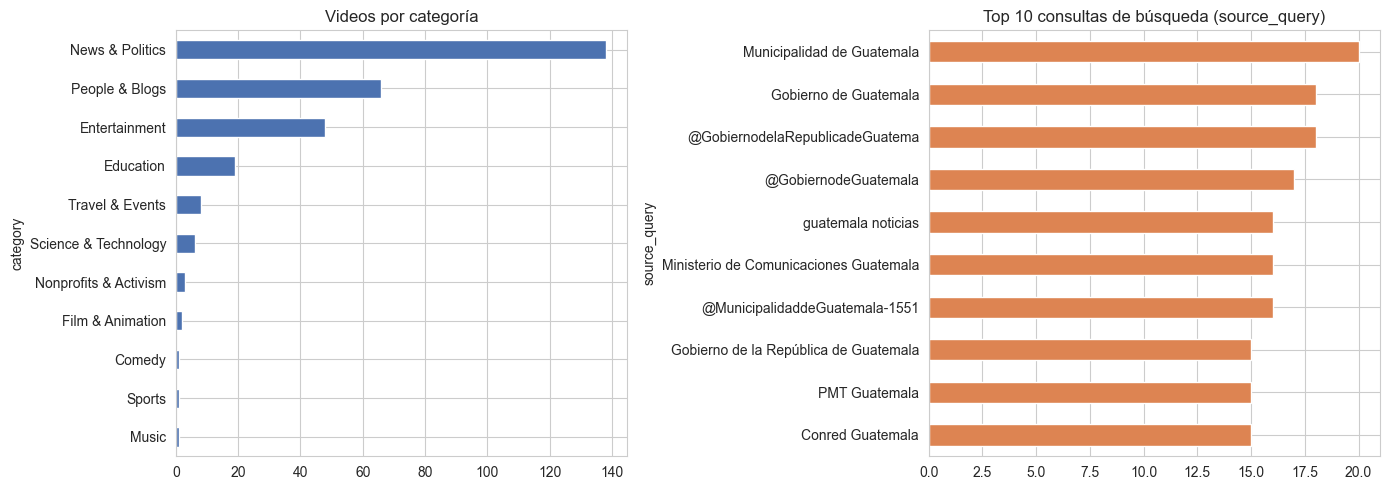

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
videos['category'].value_counts().plot(kind='barh', ax=axes[0], color='#4C72B0')
axes[0].set_title('Videos por categoría')
axes[0].invert_yaxis()

videos['source_query'].value_counts().head(10).plot(kind='barh', ax=axes[1], color='#DD8452')
axes[1].set_title('Top 10 consultas de búsqueda (source_query)')
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

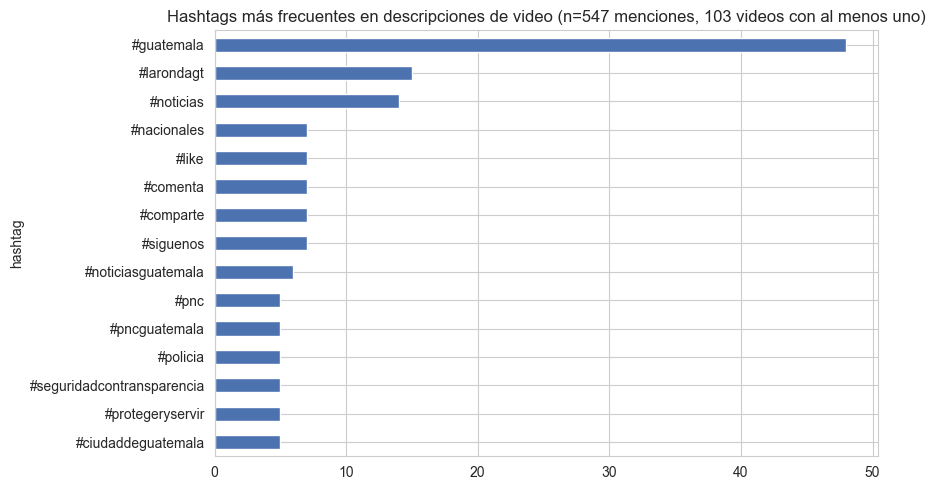

In [7]:
# Hashtags: casi ausentes en los comentarios (1 caso, ver notebook de limpieza);
# la fuente relevante de hashtags en este dataset son las descripciones de los videos.
hashtag_re = re.compile(r'#\w+')
hashtags_por_video = videos['description'].fillna('').apply(hashtag_re.findall)
todos_los_hashtags = [h.lower() for lista in hashtags_por_video for h in lista]

top_hashtags = Counter(todos_los_hashtags).most_common(15)
pd.DataFrame(top_hashtags, columns=['hashtag', 'frecuencia']).set_index('hashtag').plot(
    kind='barh', legend=False, color='#4C72B0')
plt.title(f'Hashtags más frecuentes en descripciones de video (n={len(todos_los_hashtags)} menciones, '
          f'{(hashtags_por_video.str.len() > 0).sum()} videos con al menos uno)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

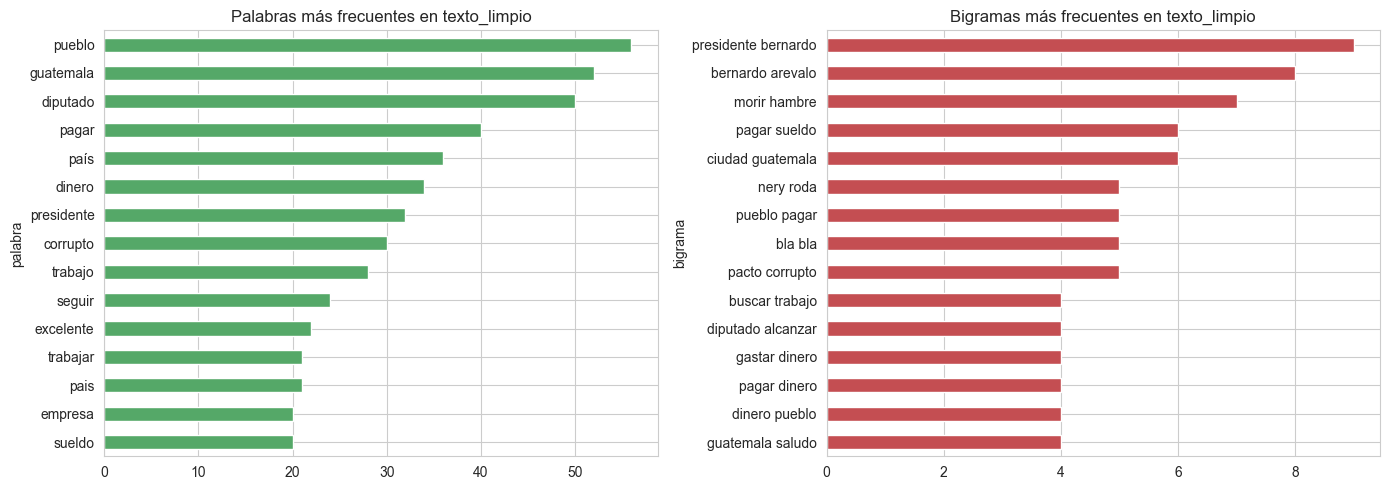

In [8]:
tokens = [t for texto in comments['texto_limpio'].dropna() for t in str(texto).split()]
bigramas = [f'{a} {b}' for texto in comments['texto_limpio'].dropna()
            for a, b in zip(str(texto).split(), str(texto).split()[1:])]

top_palabras = Counter(tokens).most_common(15)
top_bigramas = Counter(bigramas).most_common(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pd.DataFrame(top_palabras, columns=['palabra', 'frecuencia']).set_index('palabra').plot(
    kind='barh', ax=axes[0], legend=False, color='#55A868')
axes[0].set_title('Palabras más frecuentes en texto_limpio')
axes[0].invert_yaxis()

pd.DataFrame(top_bigramas, columns=['bigrama', 'frecuencia']).set_index('bigrama').plot(
    kind='barh', ax=axes[1], legend=False, color='#C44E52')
axes[1].set_title('Bigramas más frecuentes en texto_limpio')
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

**Lectura de los mínimos descriptivos:** el catálogo tiene 293 videos de 97 canales distintos (mediana de 1 video por canal, pero con canales que publicaron hasta 32), y 406 comentarios de 332 autores distintos. Sin embargo, esos 406 comentarios se concentran en solo 19 videos: el resto del catálogo no tiene comentarios en esta muestra, de modo que las cifras de "comentarios y autores por video" solo pueden describirse para esos 19 casos. `view_count` está fuertemente sesgado a la derecha (mediana 1,175, máximo superior a 8 millones), igual que `like_count` (mediana 1, máximo 405); `reply_count` es casi siempre 0. La categoría `News & Politics` domina el catálogo (47 % de los videos) y las consultas de búsqueda más frecuentes corresponden a instituciones de gobierno guatemalteco. Los hashtags aparecen sobre todo en las descripciones de los videos (no en los comentarios) y palabras como *pueblo*, *guatemala*, *diputado*, *pagar*, *corrupto* dominan el vocabulario de los comentarios — un vocabulario claramente orientado a crítica político-económica, coherente con que casi todos los comentarios pertenecen a videos de la categoría `News & Politics`.

### 3.2 Concentración de la participación

Los 3 videos con más comentarios concentran el 63.1% del total de comentarios.
Los 3 canales con más comentarios concentran el 86.5% del total de comentarios.


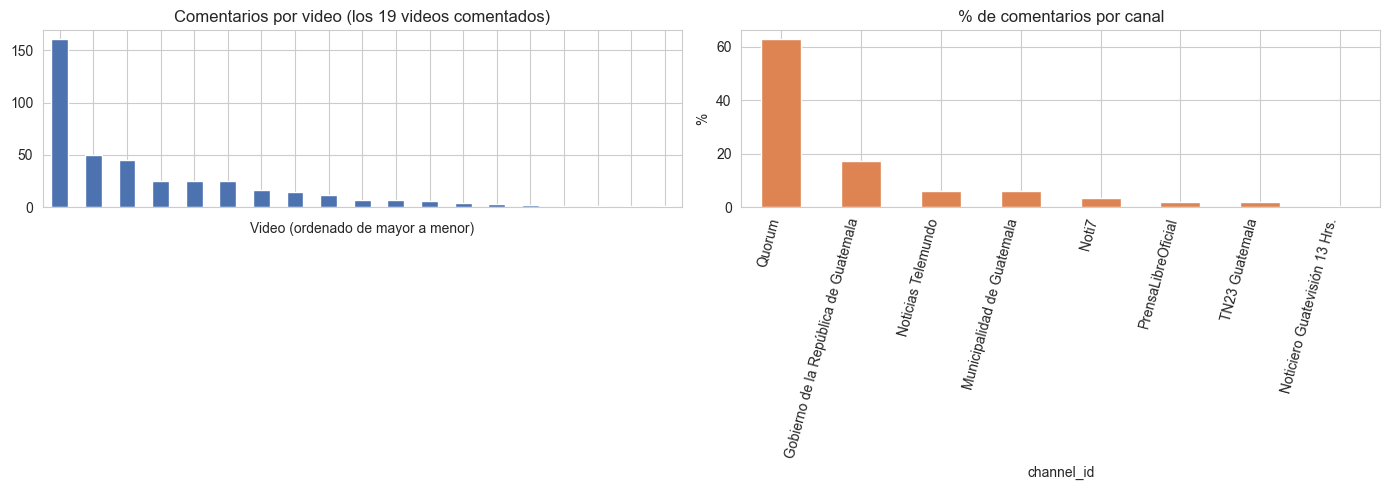

In [9]:
comentarios_por_canal = comments.groupby('channel_id').size().sort_values(ascending=False)
canal_nombre = videos.drop_duplicates('channel_id').set_index('channel_id')['channel_name']

top_n = 3
share_videos = comentarios_por_video.head(top_n).sum() / len(comments)
share_canales = comentarios_por_canal.head(top_n).sum() / len(comments)
print(f'Los {top_n} videos con más comentarios concentran el {share_videos:.1%} del total de comentarios.')
print(f'Los {top_n} canales con más comentarios concentran el {share_canales:.1%} del total de comentarios.')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
comentarios_por_video.plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('Comentarios por video (los 19 videos comentados)')
axes[0].set_xticklabels([])
axes[0].set_xlabel('Video (ordenado de mayor a menor)')

(comentarios_por_canal / len(comments) * 100).plot(kind='bar', ax=axes[1], color='#DD8452')
axes[1].set_title('% de comentarios por canal')
axes[1].set_ylabel('%')
axes[1].set_xticklabels(canal_nombre.reindex(comentarios_por_canal.index), rotation=75, ha='right')
plt.tight_layout()
plt.show()

La participación observada está extremadamente concentrada: 3 videos ya reúnen el 63.1 % de los 406 comentarios, y solo 8 de los 97 canales del catálogo recibieron algún comentario, con 3 canales acumulando el 86.5 % del total (encabezados por *Quorum*, con 256 de 406). Esto no debe leerse como que esos son "los" videos/canales más comentados de YouTube en general, sino como un efecto combinado de qué videos fueron muestreados y cuántos comentarios se recolectaron por video — una limitación de cobertura que se retoma en la sección 10.

### 3.3 Comparación entre popularidad y participación

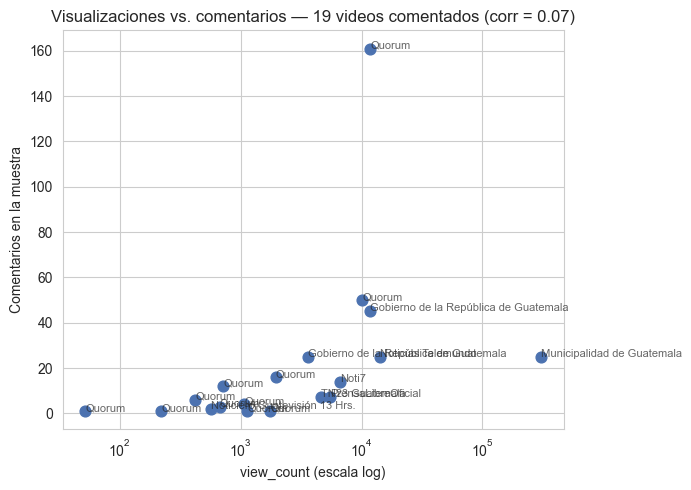

Correlación view_count vs. número de comentarios: 0.067


In [10]:
comparacion = resumen_video.join(videos.set_index('video_id')['view_count'])
correlacion = comparacion[['view_count', 'comentarios']].corr().iloc[0, 1]

plt.figure(figsize=(7, 5))
plt.scatter(comparacion['view_count'], comparacion['comentarios'], s=60, color='#4C72B0')
for vid, row in comparacion.iterrows():
    plt.annotate(row['channel_name'], (row['view_count'], row['comentarios']), fontsize=8, alpha=0.7)
plt.xscale('log')
plt.xlabel('view_count (escala log)')
plt.ylabel('Comentarios en la muestra')
plt.title(f'Visualizaciones vs. comentarios — 19 videos comentados (corr = {correlacion:.2f})')
plt.tight_layout()
plt.show()
print(f'Correlación view_count vs. número de comentarios: {correlacion:.3f}')

La correlación entre `view_count` y número de comentarios es prácticamente nula (≈ 0.07) entre los 19 videos que sí tienen comentarios: el video más comentado (161 comentarios) no es el más visto, y videos con cientos de miles de vistas no necesariamente encabezan la participación. Esto tiene una explicación metodológica importante: `view_count` es un conteo acumulado de toda la vida del video, mientras que los comentarios analizados son solo la muestra recolectada (no el total de comentarios del video), por lo que ambos conteos miden fenómenos distintos — alcance acumulado frente a una fracción observada de la conversación — y no deberían tratarse como proxies intercambiables de "popularidad".

### 3.4 Visualización adicional: nube de palabras

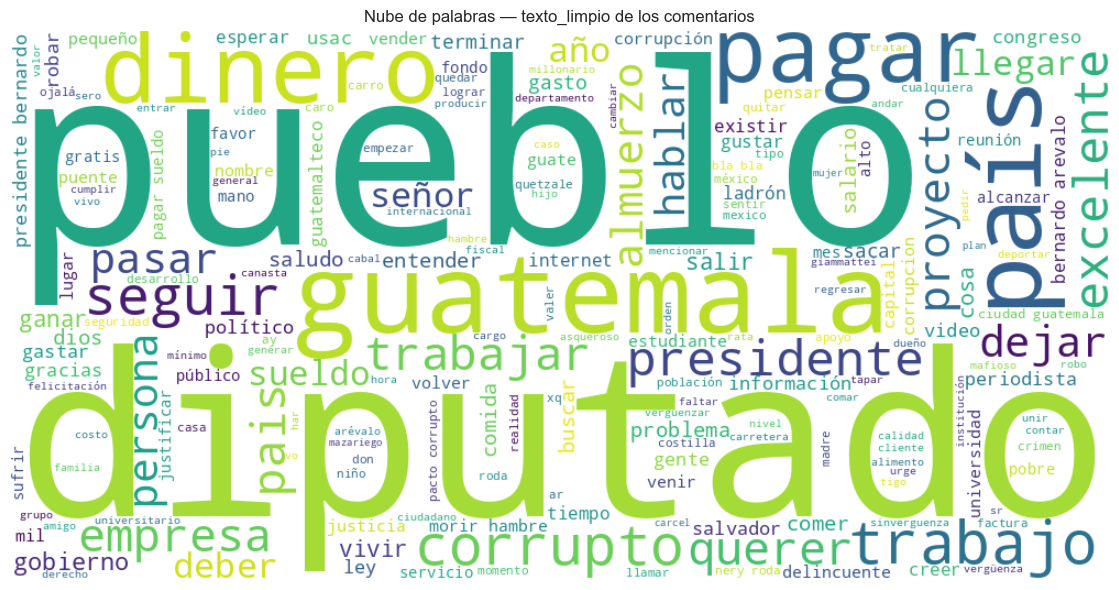

In [11]:
texto_para_nube = ' '.join(comments['texto_limpio'].dropna())
nube = WordCloud(width=1000, height=500, background_color='white', colormap='viridis').generate(texto_para_nube)

plt.figure(figsize=(12, 6))
plt.imshow(nube, interpolation='bilinear')
plt.axis('off')
plt.title('Nube de palabras — texto_limpio de los comentarios')
plt.tight_layout()
plt.show()

La nube de palabras es consistente con el ranking de frecuencias de 3.1: confirma visualmente el peso de vocabulario político-económico (*pueblo*, *diputado*, *corrupto*, *pagar*, *dinero*, *sueldo*), pero por sí sola no permite cuantificar diferencias — se usa aquí solo como complemento cualitativo a los gráficos de frecuencia ya presentados, no como sustituto.

### 3.5 Preguntas obligatorias

**¿Qué videos y canales concentran la mayor participación observada?**
El video *"Qué rico come tu diputado"* (canal *Quorum*) concentra 161 de los 406 comentarios (40 %) él solo; junto con *"La cooptación de Walter Mazariegos en la USAC"* (50) y *"Inician los trabajos de recuperación del Puente Belice II"* (45, canal *Gobierno de la República de Guatemala*) forman el top 3 (63.1 % del total). A nivel de canal, *Quorum* concentra 256 de 406 comentarios (63 %) él solo.

**¿Existen audiencias compartidas entre videos, canales o temas?**
Muy poco: de los 332 autores, solo 9 comentaron en más de un video (2.7 %), y ninguno comentó en más de 3. La inmensa mayoría de la audiencia observada participó en un único video, por lo que la red autor-video que se construirá en el ejercicio 4 será mayoritariamente dispersa, con apenas un puñado de autores que conectan dos o tres videos.

**¿Qué autores funcionan como puentes entre contenidos que de otra forma permanecerían separados?**
Los mismos 9 autores que comentaron en más de un video son, por construcción, los únicos candidatos a "puente" en la red bipartita; el análisis formal de intermediación (centralidad) se realiza en el ejercicio 8, pero ya en esta etapa exploratoria se observa que ese grupo es pequeño y que la mayoría de los pares de videos comentados no comparten ningún autor.

**¿Qué temas y sentimientos caracterizan a las principales comunidades de participación?**
A nivel léxico (sección 3.1), el vocabulario dominante —*pueblo*, *diputado*, *corrupto*, *pagar*, *dinero*, *sueldo*, bigramas como *presidente bernardo*, *pacto corrupto*— apunta a un tema recurrente de crítica a gasto público y clase política, coherente con que el 82.5 % de los comentarios pertenecen a videos de la categoría `News & Politics`. Un análisis de sentimiento propiamente dicho (polaridad, no solo temática) se desarrolla en el ejercicio 9; aquí solo se describe el contenido temático observado.

**¿La visibilidad medida mediante visualizaciones coincide con la participación observada?**
No: la correlación entre `view_count` y comentarios es prácticamente nula (0.07, sección 3.3). Ser muy visto no implica generar comentarios en esta muestra, y viceversa.

**¿Qué conclusiones están limitadas por el procedimiento de recolección y la cobertura de los datos?**
Varias: (1) solo 19 de 293 videos (6.5 %) tienen comentarios, así que ninguna afirmación sobre "participación" generaliza al catálogo completo; (2) los 406 comentarios son una muestra de los comentarios reales de cada video, no el universo, por lo que comparaciones de intensidad entre videos pueden reflejar cuántos comentarios se recolectó por video tanto como interés real; (3) ningún video con `source_group = official_gov` recibió comentarios en la muestra (los 406 provienen de videos `topic` y `channel`), lo que sesga cualquier lectura sobre "participación en canales oficiales de gobierno"; (4) las fechas relativas (`published_time`, `published_text`) impiden analizar tendencias temporales con precisión.

### 3.6 Preguntas adicionales

**¿Los videos oficiales de gobierno (`source_group = official_gov`) reciben comentarios en la misma proporción que los de tipo `topic`?**

In [12]:
videos_por_grupo = videos['source_group'].value_counts()
# source_group existe en ambos datasets con significados distintos (ver 1.2/2.2):
# el de `comments` describe cómo se obtuvo el comentario, el de `videos` cómo se
# obtuvo el video. Aquí interesa el del video, por eso se usa la columna sufijada.
comentarios_por_grupo = comments_videos['source_group_video'].value_counts()

comparacion_grupo = pd.DataFrame({'videos': videos_por_grupo, 'comentarios': comentarios_por_grupo}).fillna(0)
comparacion_grupo['comentarios_por_video'] = comparacion_grupo['comentarios'] / comparacion_grupo['videos']
comparacion_grupo

,videos,comentarios,comentarios_por_video
channel,11,43.0,3.909091
official_gov,105,0.0,0.000000
topic,177,363.0,2.050847


No. De los 105 videos `official_gov` (36 % del catálogo), **ninguno** recibió comentarios en la muestra: los 406 comentarios se reparten entre videos `topic` (363) y `channel` (43). Esto podría reflejar que los comentarios en canales institucionales suelen estar desactivados o moderados con más frecuencia, o simplemente un artefacto de qué videos fueron seleccionados para recolectar comentarios — con estos datos no se puede distinguir entre ambas explicaciones.

**¿Los comentarios con más respuestas (`reply_count`) tienden a recibir también más "me gusta" (`like_count`)?**

Correlación reply_count vs. like_count: 0.537


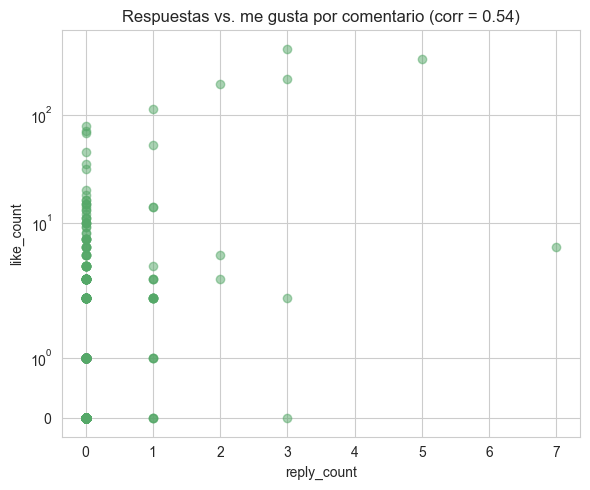

In [13]:
correlacion_reply_like = comments[['reply_count', 'like_count']].corr().iloc[0, 1]
print(f'Correlación reply_count vs. like_count: {correlacion_reply_like:.3f}')

plt.figure(figsize=(6, 5))
plt.scatter(comments['reply_count'], comments['like_count'], alpha=0.5, color='#55A868')
plt.xlabel('reply_count')
plt.ylabel('like_count')
plt.yscale('symlog')
plt.title(f'Respuestas vs. me gusta por comentario (corr = {correlacion_reply_like:.2f})')
plt.tight_layout()
plt.show()

Sí, hay una correlación positiva moderada (≈ 0.54): los comentarios que generan más respuestas también tienden a acumular más "me gusta". Es consistente con la intuición de que ambas señales reflejan el mismo fenómeno subyacente — comentarios que destacan o generan controversia dentro de la conversación —, aunque el `reply_count` no revela el contenido ni el sentido de esas respuestas (ver advertencia del enunciado: no debe interpretarse como arista entre usuarios).

**¿La categoría `News & Politics` concentra más comentarios de los que le corresponderían por su peso en el catálogo de videos?**

In [14]:
participacion_categoria = pd.DataFrame({
    'share_de_videos': videos['category'].value_counts(normalize=True),
    'share_de_comentarios': comments_videos['category'].value_counts(normalize=True),
}).fillna(0).sort_values('share_de_comentarios', ascending=False)
participacion_categoria

,share_de_videos,share_de_comentarios
category,,
News & Politics,0.470990,0.825123
Entertainment,0.163823,0.172414
Nonprofits & Activism,0.010239,0.002463
Education,0.064846,0.000000
Comedy,0.003413,0.000000
Music,0.003413,0.000000
Film & Animation,0.006826,0.000000
People & Blogs,0.225256,0.000000
Science & Technology,0.020478,0.000000


Sí, y de forma notable: `News & Politics` representa el 47 % de los videos del catálogo pero concentra el 82.5 % de los comentarios — está sobrerrepresentada en la participación observada. `Entertainment` está casi proporcional (16 % de los videos, 17 % de los comentarios), mientras que categorías como `Education`, `People & Blogs` o `Travel & Events`, pese a tener videos en el catálogo, no registran ningún comentario en la muestra. Esto refuerza el hallazgo de 3.2: la participación no se reparte según el tamaño del catálogo, sino que se concentra fuertemente en contenido político.